## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Import different algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Prepare Data

In [2]:
# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (important for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")

Training set: 120 samples
Testing set: 30 samples
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## 3. Train Multiple Algorithms

Let's train four different algorithms and compare their performance.

In [3]:
# Create dictionary of models
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=13),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)
    
    # Use scaled data for KNN and SVM, original for tree-based models
    if name in ['K-Nearest Neighbors', 'Support Vector Machine']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        X_for_cv = X  # Use original for CV, will scale inside
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        X_for_cv = X
    
    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validation score (on full dataset)
    if name in ['K-Nearest Neighbors', 'Support Vector Machine']:
        # Scale for CV
        cv_scores = cross_val_score(model, X, y, cv=10)
    else:
        cv_scores = cross_val_score(model, X_for_cv, y, cv=10)
    
    # Store results
    results[name] = {
        'model': model,
        'test_accuracy': test_accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }
    
    # Print results
    print(f"Test Accuracy: {test_accuracy:.2%}")
    print(f"Cross-Validation: {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\n✅ All models trained!")


Training: K-Nearest Neighbors
Test Accuracy: 96.67%
Cross-Validation: 98.00% (+/- 3.06%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Training: Decision Tree
Test Accuracy: 93.33%
Cross-Validation: 95.33% (+/- 4.27%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Training: Suppo

## 4. Compare Model Performance

In [4]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'Test Accuracy': [results[name]['test_accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

comparison_df = comparison_df.sort_values('CV Mean', ascending=False)
print("\n📊 Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Algorithm']
best_cv_score = comparison_df.iloc[0]['CV Mean']
print(f"\n🏆 Best Model: {best_model_name} (CV Score: {best_cv_score:.2%})")


📊 Model Performance Comparison:
             Algorithm  Test Accuracy  CV Mean   CV Std
   K-Nearest Neighbors       0.966667 0.980000 0.030551
Support Vector Machine       0.966667 0.973333 0.032660
         Random Forest       0.900000 0.960000 0.032660
         Decision Tree       0.933333 0.953333 0.042687

🏆 Best Model: K-Nearest Neighbors (CV Score: 98.00%)


## 5. Visualize Model Comparison

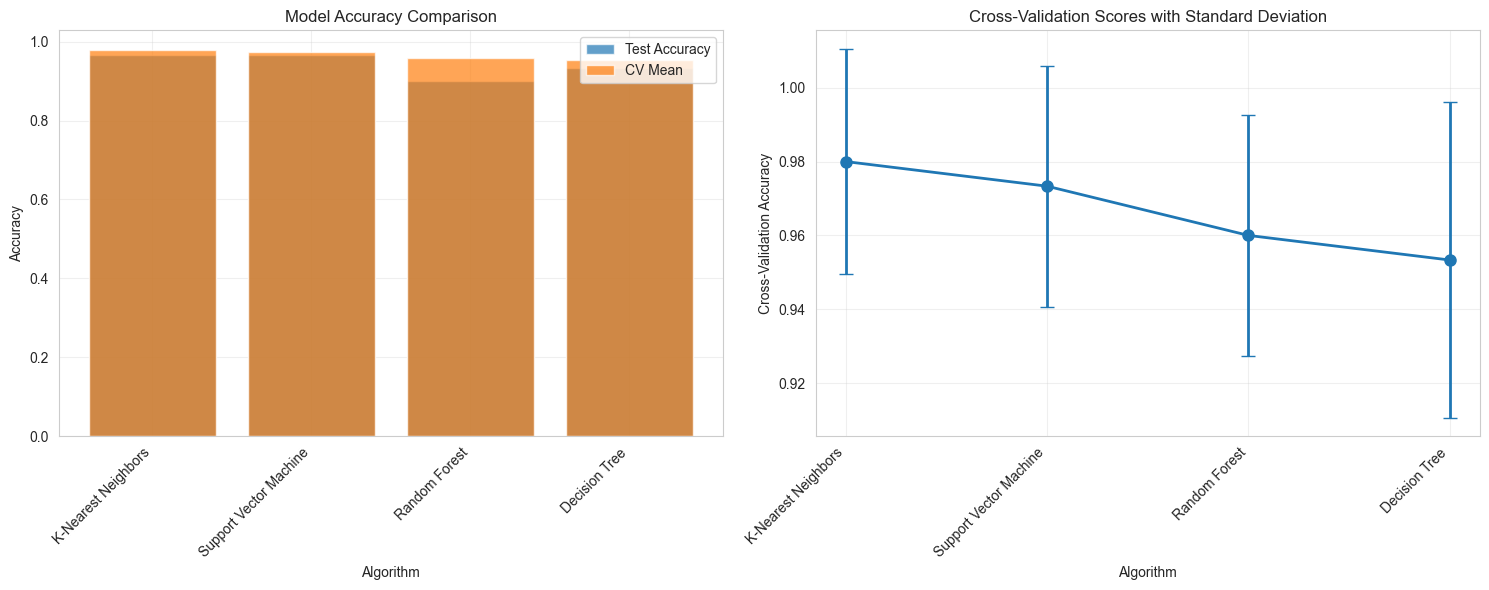

In [5]:
# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy Comparison
x_pos = np.arange(len(comparison_df))
axes[0].bar(x_pos, comparison_df['Test Accuracy'], alpha=0.7, label='Test Accuracy')
axes[0].bar(x_pos, comparison_df['CV Mean'], alpha=0.7, label='CV Mean')
axes[0].set_xlabel('Algorithm')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Algorithm'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: CV Score with Error Bars
axes[1].errorbar(x_pos, comparison_df['CV Mean'], 
                 yerr=comparison_df['CV Std'], 
                 fmt='o-', linewidth=2, markersize=8, capsize=5)
axes[1].set_xlabel('Algorithm')
axes[1].set_ylabel('Cross-Validation Accuracy')
axes[1].set_title('Cross-Validation Scores with Standard Deviation')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df['Algorithm'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Confusion Matrices for All Models

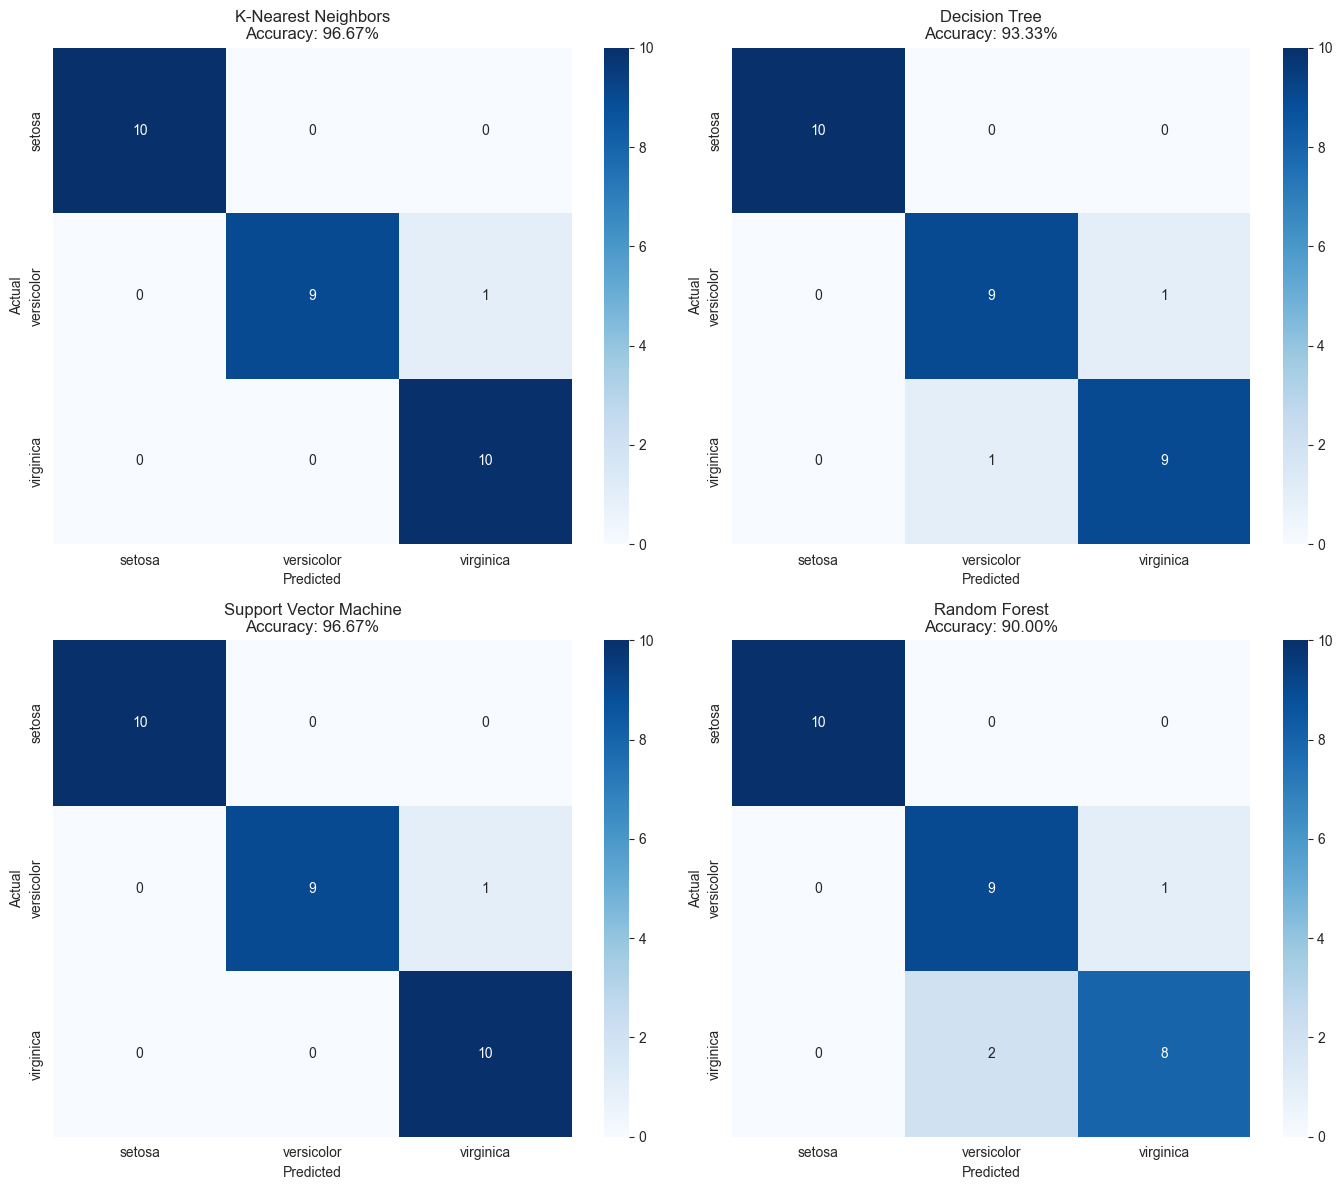

In [6]:
# Create confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris.target_names, 
                yticklabels=iris.target_names,
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nAccuracy: {result["test_accuracy"]:.2%}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 7. Feature Importance (for Tree-based Models)

Decision Trees and Random Forests can tell us which features are most important for classification.


Decision Tree - Feature Importance:
  sepal length (cm): 0.0062
  sepal width (cm): 0.0292
  petal length (cm): 0.5586
  petal width (cm): 0.4060

Random Forest - Feature Importance:
  sepal length (cm): 0.1163
  sepal width (cm): 0.0150
  petal length (cm): 0.4315
  petal width (cm): 0.4372


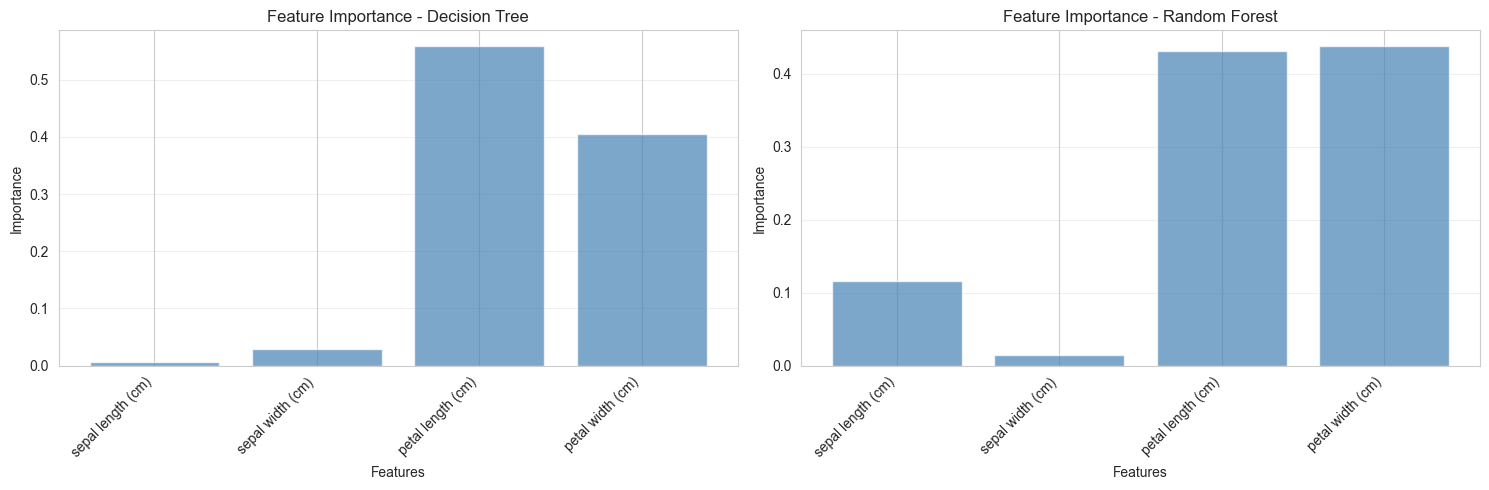

In [7]:
# Extract feature importance from tree-based models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tree_models = ['Decision Tree', 'Random Forest']

for idx, model_name in enumerate(tree_models):
    model = results[model_name]['model']
    importances = model.feature_importances_
    
    # Create bar plot
    x_pos = np.arange(len(iris.feature_names))
    axes[idx].bar(x_pos, importances, alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Features')
    axes[idx].set_ylabel('Importance')
    axes[idx].set_title(f'Feature Importance - {model_name}')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(iris.feature_names, rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Print importance values
    print(f"\n{model_name} - Feature Importance:")
    for feature, importance in zip(iris.feature_names, importances):
        print(f"  {feature}: {importance:.4f}")

plt.tight_layout()
plt.show()

## 8. Test Best Model with Custom Input

In [8]:
# Use the best performing model
best_model = results[best_model_name]['model']

# Example: Custom flower measurements
custom_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # Typical setosa measurements

# Scale if needed
if best_model_name in ['K-Nearest Neighbors', 'Support Vector Machine']:
    custom_flower_input = scaler.transform(custom_flower)
else:
    custom_flower_input = custom_flower

# Predict
prediction = best_model.predict(custom_flower_input)

# Get probabilities if available
if hasattr(best_model, 'predict_proba'):
    prediction_proba = best_model.predict_proba(custom_flower_input)
    print(f"Using: {best_model_name}\n")
    print(f"Input: Sepal Length={custom_flower[0][0]}, Sepal Width={custom_flower[0][1]}, "
          f"Petal Length={custom_flower[0][2]}, Petal Width={custom_flower[0][3]}")
    print(f"\nPredicted Species: {iris.target_names[prediction[0]].upper()}")
    print(f"\nPrediction Probabilities:")
    for i, prob in enumerate(prediction_proba[0]):
        print(f"  {iris.target_names[i]}: {prob:.2%}")
else:
    print(f"Using: {best_model_name}\n")
    print(f"Input: Sepal Length={custom_flower[0][0]}, Sepal Width={custom_flower[0][1]}, "
          f"Petal Length={custom_flower[0][2]}, Petal Width={custom_flower[0][3]}")
    print(f"\nPredicted Species: {iris.target_names[prediction[0]].upper()}")
    print("\n(Note: This model doesn't provide probability estimates)")

Using: K-Nearest Neighbors

Input: Sepal Length=5.1, Sepal Width=3.5, Petal Length=1.4, Petal Width=0.2

Predicted Species: SETOSA

Prediction Probabilities:
  setosa: 100.00%
  versicolor: 0.00%
  virginica: 0.00%


## Summary

**Key Takeaways:**

1. ✅ **Different algorithms, different strengths:**
   - **KNN**: Simple, no training phase, works well with small datasets
   - **Decision Tree**: Interpretable, fast, but can overfit
   - **SVM**: Excellent for high-dimensional data, finds optimal boundaries
   - **Random Forest**: Robust, handles overfitting well, ensemble method

2. ✅ **Feature Importance**: Tree-based models reveal which features matter most

3. ✅ **No single "best" algorithm**: Performance depends on the dataset and problem

4. ✅ **Cross-validation is crucial**: Single test set can be misleading

**When to use each algorithm:**
- **KNN**: Small datasets, simple problems, real-time predictions
- **Decision Tree**: When interpretability is important, fast inference needed
- **SVM**: High-dimensional data, clear margin of separation
- **Random Forest**: Complex problems, when you want robust performance

**Next Steps:**
- Tune hyperparameters for each algorithm
- Try ensemble methods (combining multiple models)
- Apply to more complex datasets
- Learn about neural networks for deep learning